# Turkish Stock Portfolio Analysis
Five Borsa Istanbul stocks compared with the BIST 100 index (XU100), from May 2024 to June 2025.

In [69]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import yfinance as yf
import seaborn as sns

PART 1 - HISTORICAL PRICES AND RETURNS

In [70]:
tickers = ['XU100.IS','KZBGY.IS','ISGSY.IS', 'KTLEV.IS','ARTMS.IS','A1CAP.IS']
data = pd.DataFrame()
for i in tickers:
     data[i] = yf.download(i, start='2024-03-01', end='2025-06-13')['Close']

# ARTMS has no prices for the first days, so kept only the dates where all stocks have a price
data = data.dropna()
data

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


,XU100.IS,KZBGY.IS,ISGSY.IS,KTLEV.IS,ARTMS.IS,A1CAP.IS
Date,,,,,,
2024-05-02,10208.646484,1.8210,5.432919,4.465657,55.000000,6.464
2024-05-03,10276.845703,1.8210,5.568997,4.415198,56.200001,6.464
2024-05-06,10267.044922,1.8210,5.429517,4.856717,56.750000,6.440
2024-05-07,10336.445312,1.8300,5.204989,4.856717,55.650002,6.752
2024-05-08,10247.745117,1.8555,5.239008,4.624603,55.549999,6.888
...,...,...,...,...,...,...
2025-06-04,9474.950195,3.1380,5.960222,2.109352,29.700001,6.920
2025-06-05,9486.548828,3.2100,5.990839,2.153542,29.020000,6.870
2025-06-10,9659.249023,3.3090,5.984036,2.241922,29.940001,7.550


In [71]:
data.tail()

,XU100.IS,KZBGY.IS,ISGSY.IS,KTLEV.IS,ARTMS.IS,A1CAP.IS
Date,,,,,,
2025-06-04,9474.950195,3.138,5.960222,2.109352,29.700001,6.92
2025-06-05,9486.548828,3.210,5.990839,2.153542,29.020000,6.87
2025-06-10,9659.249023,3.309,5.984036,2.241922,29.940001,7.55
2025-06-11,9686.047852,3.261,6.011251,2.218354,29.780001,8.30
2025-06-12,9520.149414,3.354,5.783321,2.180056,28.600000,8.15


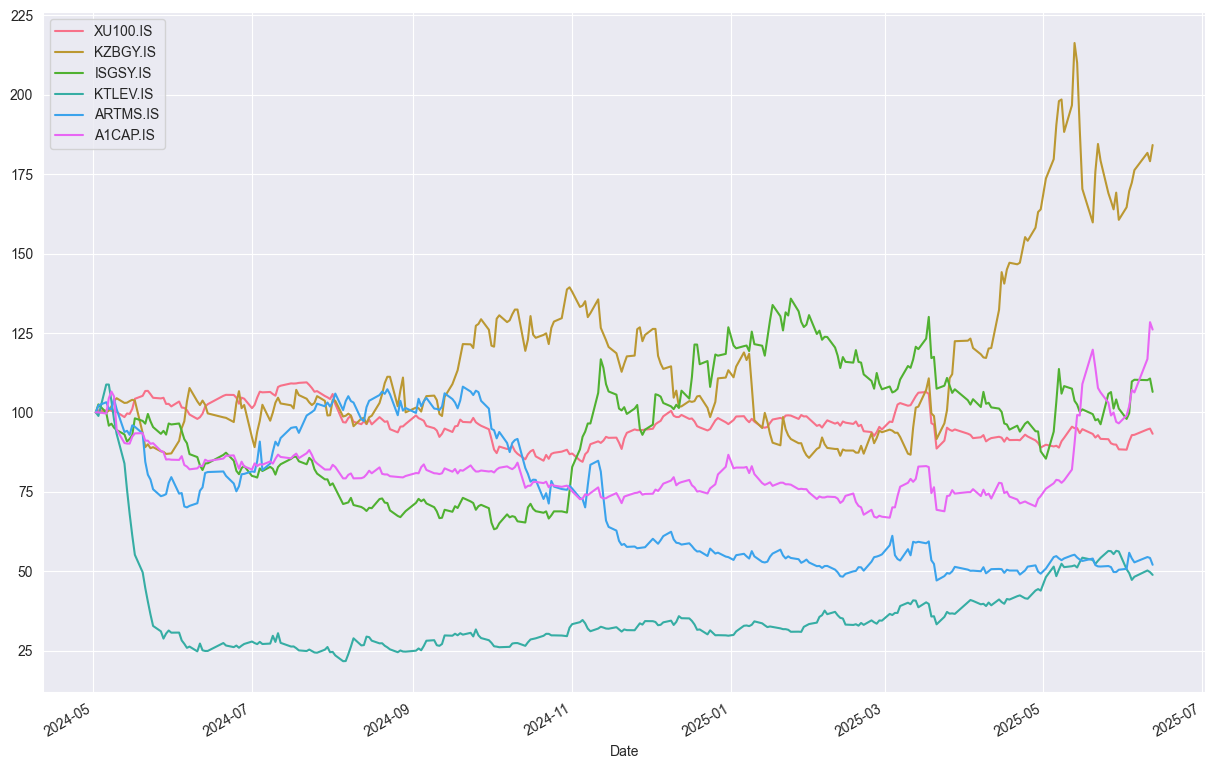

In [72]:
(data / data.iloc[0] * 100).plot(figsize=(15,10))
plt.show()

In [73]:
# simple return d_returns = (data/ data.shift(1)) - 1
d_returns = data.pct_change(fill_method=None)
d_returns

,XU100.IS,KZBGY.IS,ISGSY.IS,KTLEV.IS,ARTMS.IS,A1CAP.IS
Date,,,,,,
2024-05-02,NaN,NaN,NaN,NaN,NaN,NaN
2024-05-03,0.006681,0.000000,0.025047,-0.011299,0.021818,0.000000
2024-05-06,-0.000954,0.000000,-0.025046,0.100000,0.009786,-0.003713
2024-05-07,0.006760,0.004942,-0.041353,0.000000,-0.019383,0.048447
2024-05-08,-0.008581,0.013934,0.006536,-0.047792,-0.001797,0.020142
...,...,...,...,...,...,...
2025-06-04,0.021343,0.015534,0.099812,-0.043114,-0.031943,0.050076
2025-06-05,0.001224,0.022945,0.005137,0.020950,-0.022896,-0.007225
2025-06-10,0.018205,0.030841,-0.001136,0.041040,0.031702,0.098981


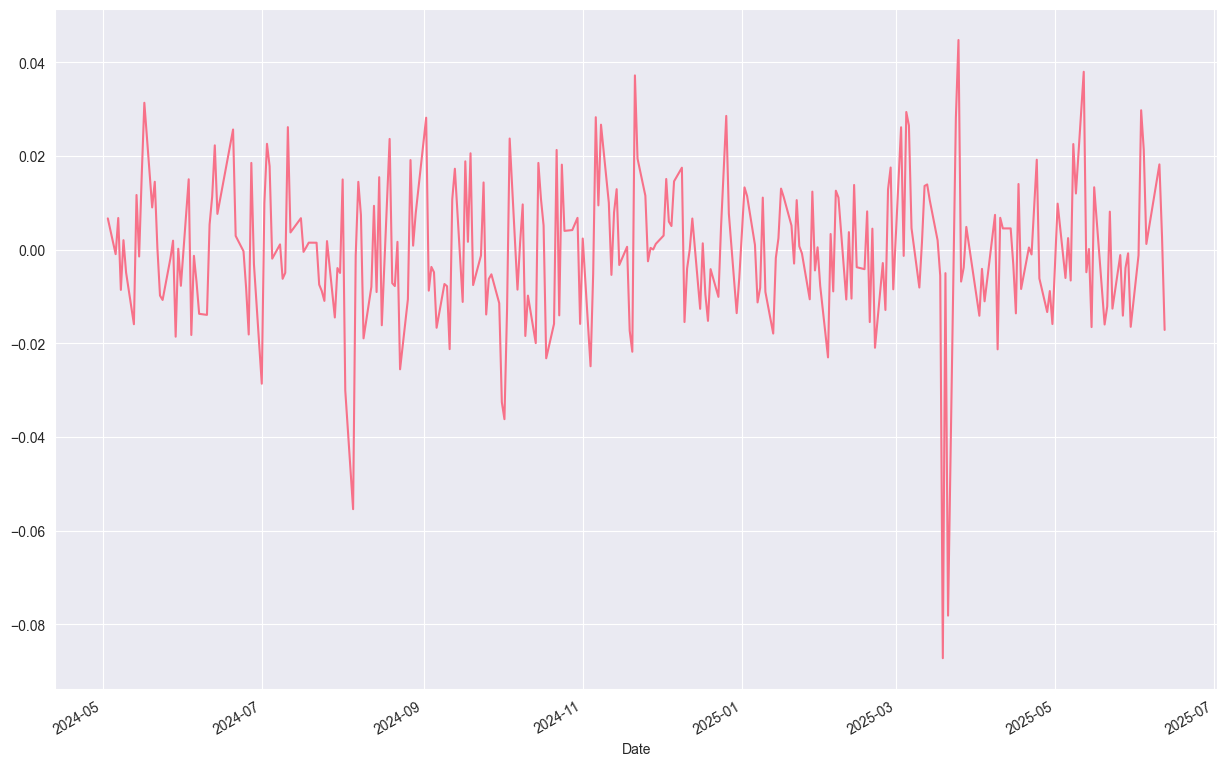

In [74]:
d_returns['XU100.IS'].plot(figsize= (15,10))
plt.show()

In [75]:
# total return over the period (compounded, not summed)
total_returns_pct = ((1 + d_returns).prod() - 1) * 100
total_returns_pct

XU100.IS    -6.744254
KZBGY.IS    84.184521
ISGSY.IS     6.449606
KTLEV.IS   -51.181747
ARTMS.IS   -47.999999
A1CAP.IS    26.082911
dtype: float64

In [76]:
log_returns = np.log(data / data.shift(1))
log_returns

,XU100.IS,KZBGY.IS,ISGSY.IS,KTLEV.IS,ARTMS.IS,A1CAP.IS
Date,,,,,,
2024-05-02,NaN,NaN,NaN,NaN,NaN,NaN
2024-05-03,0.006658,0.000000,0.024738,-0.011364,0.021584,0.000000
2024-05-06,-0.000954,0.000000,-0.025365,0.095310,0.009739,-0.003720
2024-05-07,0.006737,0.004930,-0.042233,0.000000,-0.019574,0.047310
2024-05-08,-0.008618,0.013838,0.006515,-0.048972,-0.001799,0.019942
...,...,...,...,...,...,...
2025-06-04,0.021119,0.015415,0.095139,-0.044071,-0.032464,0.048862
2025-06-05,0.001223,0.022685,0.005124,0.020733,-0.023162,-0.007252
2025-06-10,0.018041,0.030375,-0.001136,0.040220,0.031210,0.094383


In [77]:
# Daily volatility
daily_vol = log_returns.std()

# Annual volatility (assuming 252 trading days)
annual_vol = log_returns.std() * np.sqrt(252)

print("Daily Volatility:")
print(daily_vol)
print("\nAnnual Volatility:")
print(annual_vol)

Daily Volatility:
XU100.IS    0.015786
KZBGY.IS    0.038276
ISGSY.IS    0.033395
KTLEV.IS    0.042284
ARTMS.IS    0.033128
A1CAP.IS    0.026552
dtype: float64

Annual Volatility:
XU100.IS    0.250592
KZBGY.IS    0.607619
ISGSY.IS    0.530133
KTLEV.IS    0.671236
ARTMS.IS    0.525897
A1CAP.IS    0.421495
dtype: float64


PART 2 - PORTFOLIO ANALYSIS

PORTFOLIO RETURN

In [78]:
# the prices are already downloaded in Part 1
index = data[['XU100.IS']]
data = data.drop(columns='XU100.IS')
data

,KZBGY.IS,ISGSY.IS,KTLEV.IS,ARTMS.IS,A1CAP.IS
Date,,,,,
2024-05-02,1.8210,5.432919,4.465657,55.000000,6.464
2024-05-03,1.8210,5.568997,4.415198,56.200001,6.464
2024-05-06,1.8210,5.429517,4.856717,56.750000,6.440
2024-05-07,1.8300,5.204989,4.856717,55.650002,6.752
2024-05-08,1.8555,5.239008,4.624603,55.549999,6.888
...,...,...,...,...,...
2025-06-04,3.1380,5.960222,2.109352,29.700001,6.920
2025-06-05,3.2100,5.990839,2.153542,29.020000,6.870
2025-06-10,3.3090,5.984036,2.241922,29.940001,7.550


In [79]:
index_returns = index.pct_change(fill_method=None)
index_returns

,XU100.IS
Date,
2024-05-02,NaN
2024-05-03,0.006681
2024-05-06,-0.000954
2024-05-07,0.006760
2024-05-08,-0.008581
...,...
2025-06-04,0.021343
2025-06-05,0.001224
2025-06-10,0.018205


RISK-FREE RATE

Interest rates in Turkey were very high in this period, so a TL deposit is a serious alternative to buying stocks. I use the average TCMB policy rate as the risk-free rate.

In [80]:
RISK_FREE = 0.48  # approx. average TCMB policy rate, May 2024 - Jun 2025

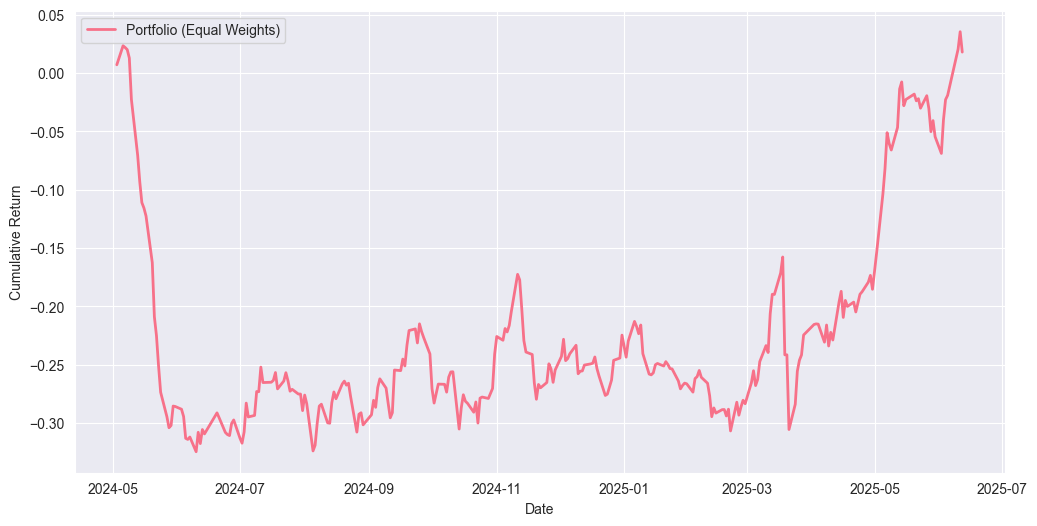

In [81]:
d_returns = data.pct_change(fill_method=None)

weights = np.array([0.2, 0.2, 0.2, 0.2, 0.2])

# 1. Calculate daily portfolio returns
portfolio_returns = d_returns.dot(weights)

# 2. Calculate cumulative returns for portfolio and XU100 index
portfolio_cum_returns = (1 + portfolio_returns).cumprod() - 1

# 3. Plot cumulative returns
plt.figure(figsize=(12, 6))
plt.plot(portfolio_cum_returns, label='Portfolio (Equal Weights)', linewidth=2)
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True)
plt.show()

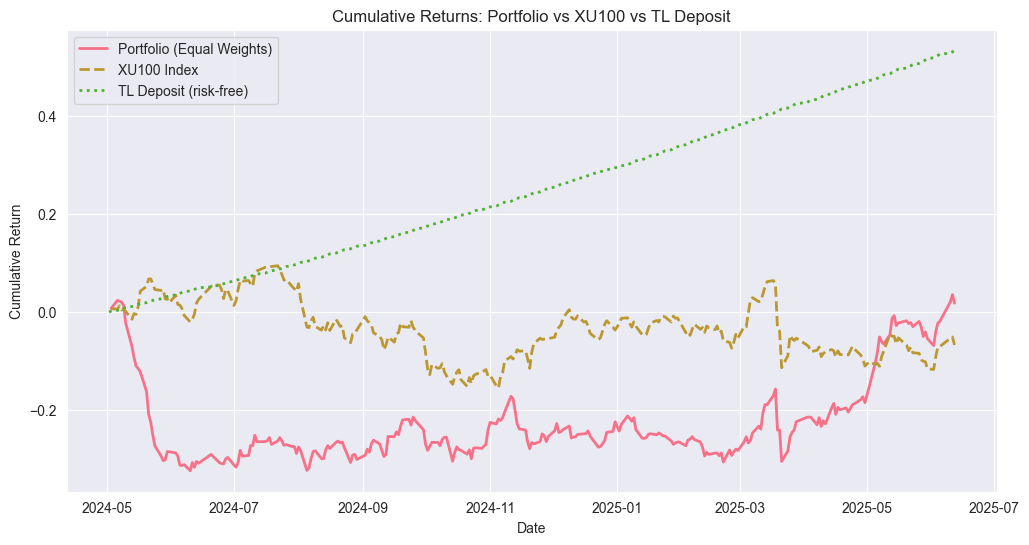

In [82]:
index_cum_returns = (1 + index_returns).cumprod() - 1

# what a TL deposit would have earned at the risk-free rate over the same days
deposit_cum_returns = pd.Series((1 + RISK_FREE) ** (np.arange(len(index_cum_returns)) / 252) - 1,
                                index=index_cum_returns.index)

plt.figure(figsize=(12, 6))
plt.plot(portfolio_cum_returns, label='Portfolio (Equal Weights)', linewidth=2)
plt.plot(index_cum_returns, label='XU100 Index', linewidth=2, linestyle='--')
plt.plot(deposit_cum_returns, label='TL Deposit (risk-free)', linewidth=2, linestyle=':')
plt.title('Cumulative Returns: Portfolio vs XU100 vs TL Deposit')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True)
plt.show()

Correlation Analysis

In [83]:
correlation_matrix = d_returns.corr()
correlation_matrix

,KZBGY.IS,ISGSY.IS,KTLEV.IS,ARTMS.IS,A1CAP.IS
KZBGY.IS,1.000000,0.108028,0.133865,0.194153,0.162177
ISGSY.IS,0.108028,1.000000,0.127351,0.217779,0.185977
KTLEV.IS,0.133865,0.127351,1.000000,0.272544,0.154062
ARTMS.IS,0.194153,0.217779,0.272544,1.000000,0.322054
A1CAP.IS,0.162177,0.185977,0.154062,0.322054,1.000000


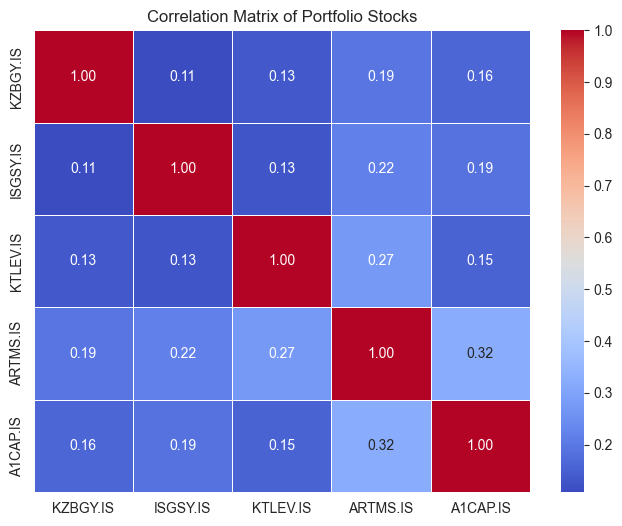

In [84]:
#  Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Portfolio Stocks')
plt.show()

In [85]:
# Combine stock returns and XU100 returns into one DataFrame
combined_returns = d_returns.copy()
combined_returns['XU100'] = index_returns

# Calculate correlation matrix
corr_with_index = combined_returns.corr()

# Extract correlations of each stock with XU100
stock_vs_xu100_corr = corr_with_index.loc[d_returns.columns, 'XU100']

print("Correlation between each stock and XU100 index:")
print(stock_vs_xu100_corr)

Correlation between each stock and XU100 index:
KZBGY.IS    0.275187
ISGSY.IS    0.403620
KTLEV.IS    0.185890
ARTMS.IS    0.342542
A1CAP.IS    0.446842
Name: XU100, dtype: float64


Portfolio Optimization (Modern Portfolio Theory)

In [86]:
mean_daily_returns = d_returns.mean()
annual_returns = mean_daily_returns * 252
cov_matrix = d_returns.cov() * 252
print("Annual Expected Returns:")
print(annual_returns)

print("Annual Covariance Matrix:")
print(cov_matrix)

Annual Expected Returns:
KZBGY.IS    0.743986
ISGSY.IS    0.198441
KTLEV.IS   -0.432735
ARTMS.IS   -0.461608
A1CAP.IS    0.301226
dtype: float64
Annual Covariance Matrix:
          KZBGY.IS  ISGSY.IS  KTLEV.IS  ARTMS.IS  A1CAP.IS
KZBGY.IS  0.367434  0.035160  0.054236  0.061427  0.041624
ISGSY.IS  0.035160  0.288309  0.045705  0.061034  0.042282
KTLEV.IS  0.054236  0.045705  0.446743  0.095080  0.043601
ARTMS.IS  0.061427  0.061034  0.095080  0.272428  0.071174
A1CAP.IS  0.041624  0.042282  0.043601  0.071174  0.179282


Simulating 10,000 Portfolios to Find the Optimal Portfolio

In [87]:
num_portfolios = 10000
num_assets = len(d_returns.columns)
results = np.zeros((num_portfolios, 3 + num_assets))  # Return, Volatility, Sharpe + Weights
results



array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(10000, 8))

In [88]:
np.random.seed(42)  # For reproducibility

for i in range(num_portfolios):
    weights = np.random.random(num_assets)
    weights /= np.sum(weights)

    # Portfolio return and volatility
    portfolio_return = np.dot(weights, annual_returns)
    portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))

    # Sharpe Ratio (return above the risk-free rate, per unit of risk)
    sharpe_ratio = (portfolio_return - RISK_FREE) / portfolio_volatility

    results[i, 0] = portfolio_return
    results[i, 1] = portfolio_volatility
    results[i, 2] = sharpe_ratio
    results[i, 3:] = weights

# Convert to DataFrame for analysis
columns = ['Return', 'Volatility', 'Sharpe'] + list(d_returns.columns)
results_df = pd.DataFrame(results, columns=columns)

# Preview
results_df.head()

,Return,Volatility,Sharpe,KZBGY.IS,ISGSY.IS,KTLEV.IS,ARTMS.IS,A1CAP.IS
0,-0.028022,0.354366,-1.433608,0.133197,0.338101,0.260318,0.212900,0.055485
1,-0.130336,0.373116,-1.635781,0.065285,0.024308,0.362501,0.251571,0.296334
2,-0.088264,0.395640,-1.436314,0.009284,0.437468,0.375464,0.095773,0.082010
3,-0.081771,0.350052,-1.604823,0.105673,0.175297,0.302353,0.248877,0.167800
4,0.174034,0.339970,-0.899980,0.327909,0.074759,0.156568,0.196343,0.244421


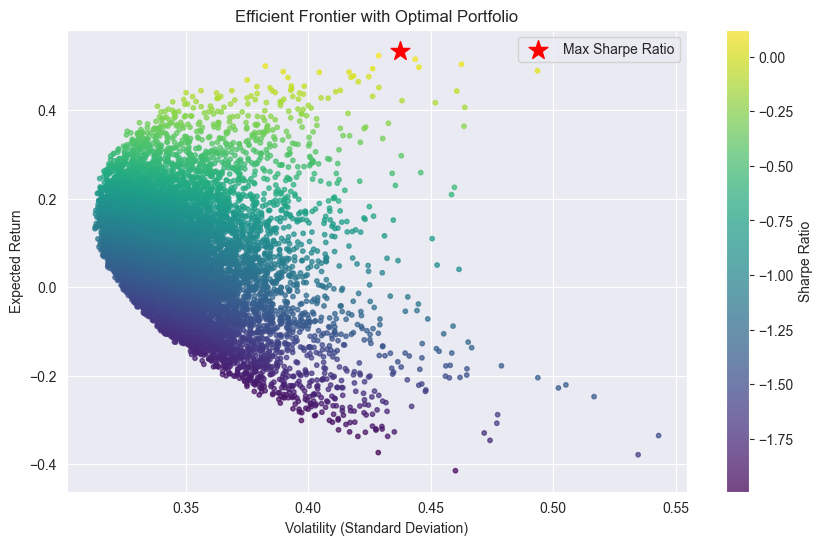

In [89]:

# Find the portfolio with the highest Sharpe ratio
max_sharpe_idx = results_df['Sharpe'].idxmax()
optimal_portfolio = results_df.loc[max_sharpe_idx]

# Plot Efficient Frontier
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    results_df['Volatility'], results_df['Return'],
    c=results_df['Sharpe'], cmap='viridis', alpha=0.7, s=10
)
plt.colorbar(scatter, label='Sharpe Ratio')
plt.scatter(
    optimal_portfolio['Volatility'], optimal_portfolio['Return'],
    color='red', marker='*', s=200, label='Max Sharpe Ratio'
)
plt.title('Efficient Frontier with Optimal Portfolio')
plt.xlabel('Volatility (Standard Deviation)')
plt.ylabel('Expected Return')
plt.legend()
plt.grid(True)
plt.show()

In [90]:
print("Optimal Portfolio Weights:")
for stock, weight in zip(d_returns.columns, optimal_portfolio[3:]):
    print(f"{stock}: {weight:.2%}")

print(f"\nExpected Return: {optimal_portfolio['Return']:.2%}")
print(f"Volatility: {optimal_portfolio['Volatility']:.2%}")
print(f"Sharpe Ratio: {optimal_portfolio['Sharpe']:.2f}")

Optimal Portfolio Weights:
KZBGY.IS: 65.68%
ISGSY.IS: 12.15%
KTLEV.IS: 0.70%
ARTMS.IS: 5.31%
A1CAP.IS: 16.16%

Expected Return: 53.39%
Volatility: 43.75%
Sharpe Ratio: 0.12


Comparison with the equal weighted portfolio

In [91]:
# Equal weights
equal_weights = np.repeat(1/len(d_returns.columns), len(d_returns.columns))

# Expected return and volatility (annualized)
equal_return = np.dot(equal_weights, annual_returns)
equal_volatility = np.sqrt(np.dot(equal_weights.T, np.dot(cov_matrix, equal_weights)))
equal_sharpe = (equal_return - RISK_FREE) / equal_volatility

# Print results
print(f"Equal-Weighted Portfolio:")
print(f"Expected Return: {equal_return:.2%}")
print(f"Volatility: {equal_volatility:.2%}")
print(f"Sharpe Ratio: {equal_sharpe:.2f}")

Equal-Weighted Portfolio:
Expected Return: 6.99%
Volatility: 32.60%
Sharpe Ratio: -1.26


STATISTICAL MODELLING

CAPM

In [92]:
# Make index_returns a Series
if isinstance(index_returns, pd.DataFrame):
    index_returns = index_returns.iloc[:, 0]  # take the first column as a Series

# CAPM analysis
for stock in d_returns.columns:
    # Merge and clean the data
    reg_data = pd.DataFrame({
        'stock': d_returns[stock],
        'market': index_returns
    }).dropna()

    # Fit the model
    Y = reg_data['stock']
    X = sm.add_constant(reg_data['market'])
    model = sm.OLS(Y, X).fit()

    # Print results
    print(f"\n--- {stock} ---")
    print(f"Alpha:       {model.params.iloc[0]:.6f}")
    print(f"Beta:        {model.params.iloc[1]:.4f}")
    print(f"R-squared:   {model.rsquared:.4f}")
    print(f"P-value (β): {model.pvalues.iloc[1]:.4f}")

# Data check
print("\nData Check:")
print(f"Rows before cleaning: {len(d_returns)}")
print(f"Rows used in regression: {len(reg_data)}")
print(f"Period: {reg_data.index[0]:%Y-%m-%d} to {reg_data.index[-1]:%Y-%m-%d}")


--- KZBGY.IS ---
Alpha:       0.003040
Beta:        0.6712
R-squared:   0.0757
P-value (β): 0.0000

--- ISGSY.IS ---
Alpha:       0.000901
Beta:        0.8720
R-squared:   0.1629
P-value (β): 0.0000

--- KTLEV.IS ---
Alpha:       -0.001652
Beta:        0.4999
R-squared:   0.0346
P-value (β): 0.0020

--- ARTMS.IS ---
Alpha:       -0.001738
Beta:        0.7194
R-squared:   0.1173
P-value (β): 0.0000

--- A1CAP.IS ---
Alpha:       0.001295
Beta:        0.7613
R-squared:   0.1997
P-value (β): 0.0000

Data Check:
Rows before cleaning: 276
Rows used in regression: 275
Period: 2024-05-03 to 2025-06-12


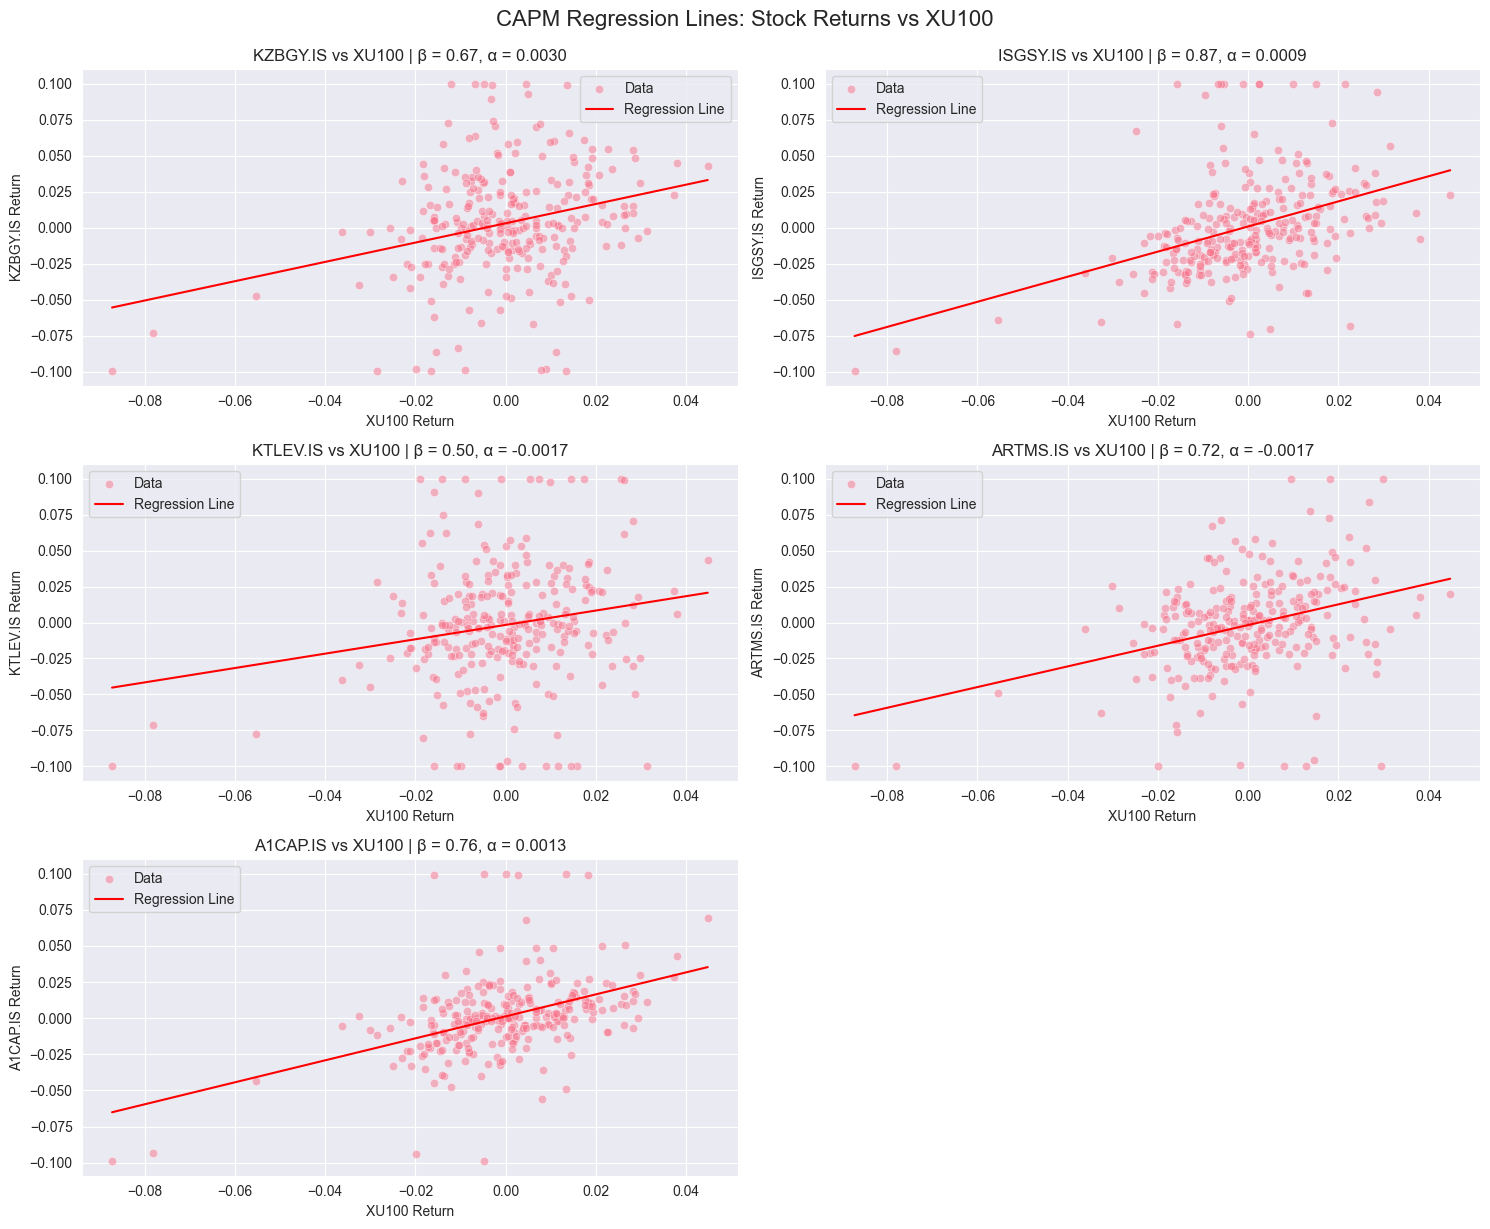

In [93]:
plt.figure(figsize=(15, 12))
# Loop through each stock
for i, stock in enumerate(d_returns.columns, 1):
    # Merge stock and market returns
    reg_data = pd.DataFrame({
        'stock': d_returns[stock],
        'market': index_returns
    }).dropna()

    Y = reg_data['stock']
    X = sm.add_constant(reg_data['market'])
    model = sm.OLS(Y, X).fit()

    # Predicted values for line
    pred_Y = model.predict(X)

    # Plot
    plt.subplot(3, 2, i)
    sns.scatterplot(x=reg_data['market'], y=reg_data['stock'], alpha=0.5, label='Data')
    sns.lineplot(x=reg_data['market'], y=pred_Y, color='red', label='Regression Line')

    plt.title(f'{stock} vs XU100 | β = {model.params["market"]:.2f}, α = {model.params["const"]:.4f}')
    plt.xlabel('XU100 Return')
    plt.ylabel(f'{stock} Return')
    plt.legend()

plt.tight_layout()
plt.suptitle('CAPM Regression Lines: Stock Returns vs XU100', fontsize=16, y=1.02)
plt.show()

ROLLING BETAS


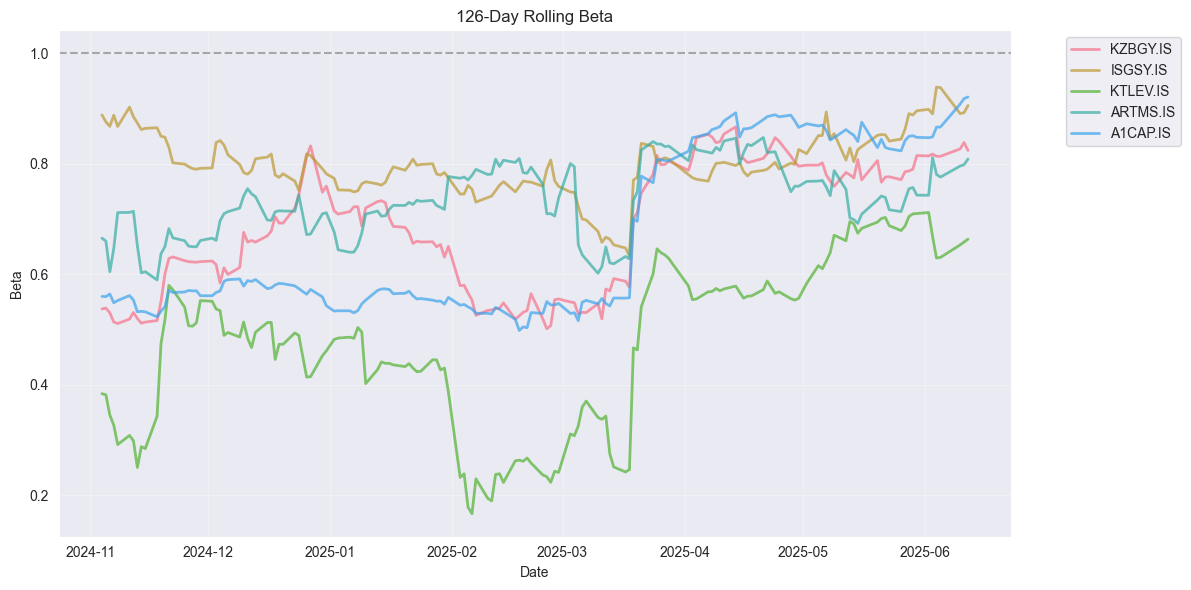


--- KZBGY.IS Rolling Beta Statistics ---
Mean Beta:   0.6823
Median Beta: 0.6871
Min Beta:    0.5013
Max Beta:    0.8670
Std Beta:    0.1131

--- ISGSY.IS Rolling Beta Statistics ---
Mean Beta:   0.7990
Median Beta: 0.7948
Min Beta:    0.6330
Max Beta:    0.9390
Std Beta:    0.0563

--- KTLEV.IS Rolling Beta Statistics ---
Mean Beta:   0.4704
Median Beta: 0.4862
Min Beta:    0.1663
Max Beta:    0.7119
Std Beta:    0.1484

--- ARTMS.IS Rolling Beta Statistics ---
Mean Beta:   0.7329
Median Beta: 0.7339
Min Beta:    0.5897
Max Beta:    0.8477
Std Beta:    0.0656

--- A1CAP.IS Rolling Beta Statistics ---
Mean Beta:   0.6614
Median Beta: 0.5707
Min Beta:    0.4982
Max Beta:    0.9211
Std Beta:    0.1462


In [94]:
sns.set_palette("husl")

def calculate_rolling_beta(stock_returns, market_returns, window=126):
    # Merge and clean the data
    reg_data = pd.DataFrame({
        'stock': stock_returns,
        'market': market_returns
    }).dropna()

    # Rolling covariance and variance
    rolling_covariance = reg_data['stock'].rolling(window=window).cov(reg_data['market'])
    rolling_variance = reg_data['market'].rolling(window=window).var()

    # Rolling beta
    rolling_beta = rolling_covariance / rolling_variance

    return rolling_beta

# Rolling beta for each stock
window_size = 126  # about 6 months (with ~15 months of data, 252 days leaves too few points)

plt.figure(figsize=(12, 6))

for stock in d_returns.columns:
    rolling_beta = calculate_rolling_beta(
        stock_returns=d_returns[stock],
        market_returns=index_returns,
        window=window_size
    )

    plt.plot(rolling_beta.index, rolling_beta.values, label=stock, linewidth=2, alpha=0.7)

plt.axhline(y=1, color='black', linestyle='--', alpha=0.3)  # Beta = 1 reference line
plt.title(f'{window_size}-Day Rolling Beta', fontsize=12)
plt.xlabel('Date')
plt.ylabel('Beta')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Summary statistics
for stock in d_returns.columns:
    rolling_beta = calculate_rolling_beta(
        stock_returns=d_returns[stock],
        market_returns=index_returns,
        window=window_size
    )

    print(f"\n--- {stock} Rolling Beta Statistics ---")
    print(f"Mean Beta:   {rolling_beta.mean():.4f}")
    print(f"Median Beta: {rolling_beta.median():.4f}")
    print(f"Min Beta:    {rolling_beta.min():.4f}")
    print(f"Max Beta:    {rolling_beta.max():.4f}")
    print(f"Std Beta:    {rolling_beta.std():.4f}")

TIME SERIES ANALYSIS

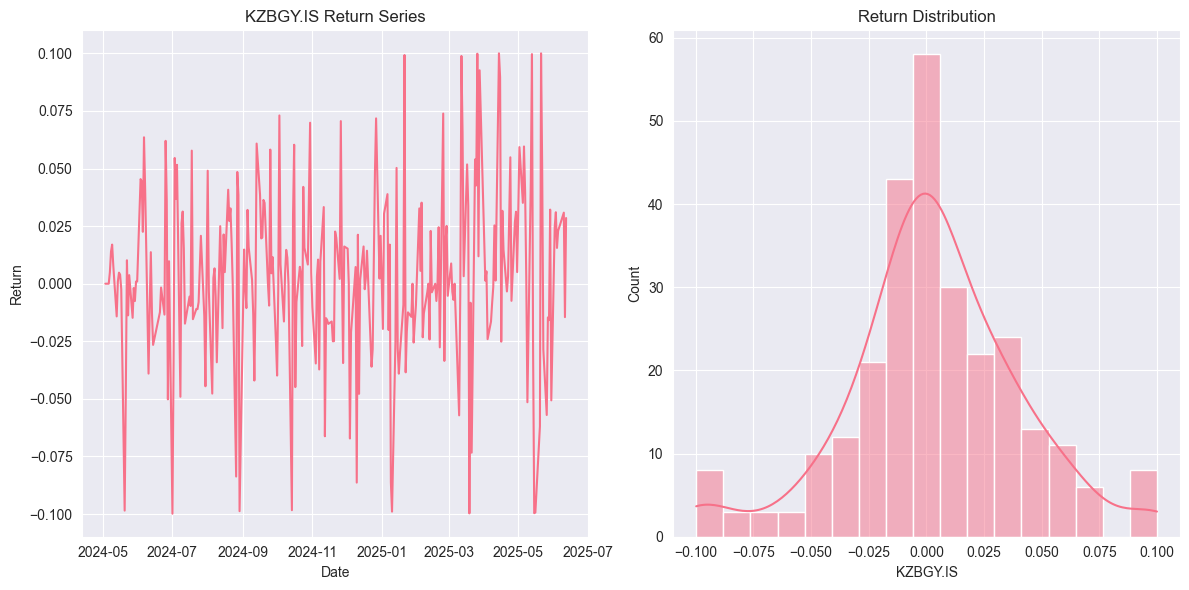


=== KZBGY.IS Analysis ===
Mean Return: 0.0030
Volatility: 0.0382
Skewness: -0.1554
Kurtosis: 0.9098

Stationarity (ADF) Test p-value: 0.0000


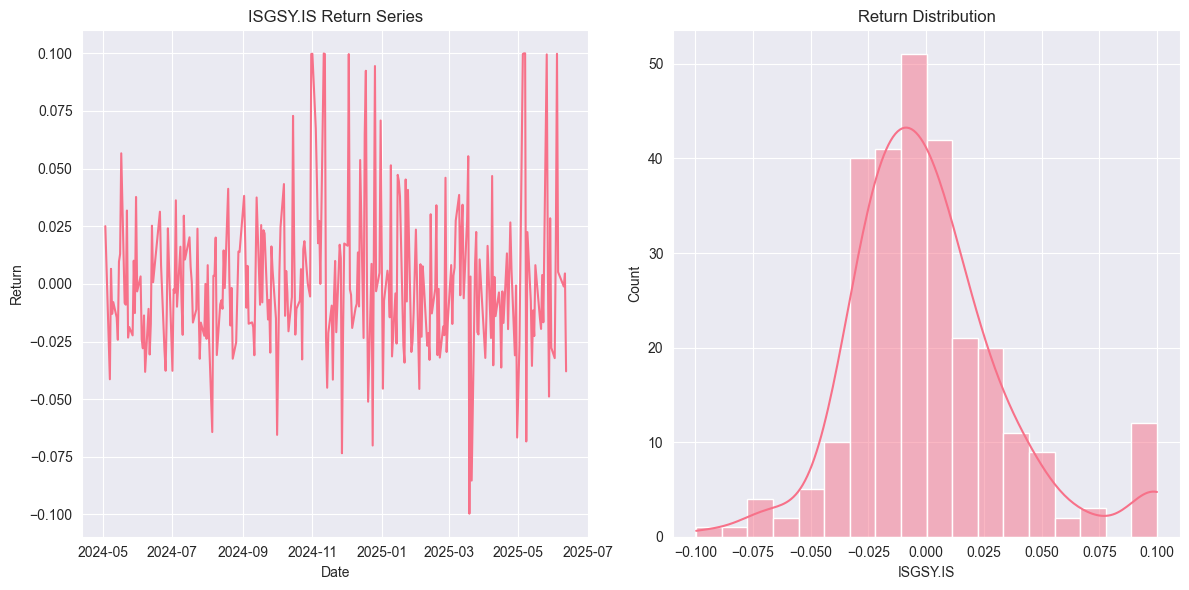


=== ISGSY.IS Analysis ===
Mean Return: 0.0008
Volatility: 0.0338
Skewness: 0.8356
Kurtosis: 1.7022

Stationarity (ADF) Test p-value: 0.0000


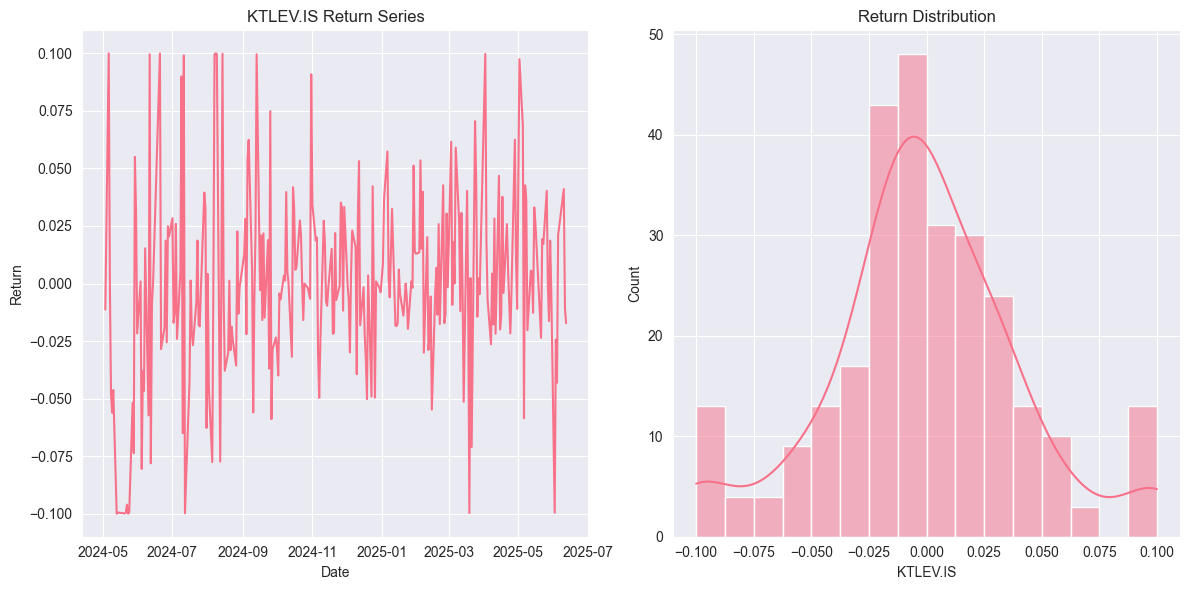


=== KTLEV.IS Analysis ===
Mean Return: -0.0017
Volatility: 0.0421
Skewness: 0.0101
Kurtosis: 0.6763

Stationarity (ADF) Test p-value: 0.0000


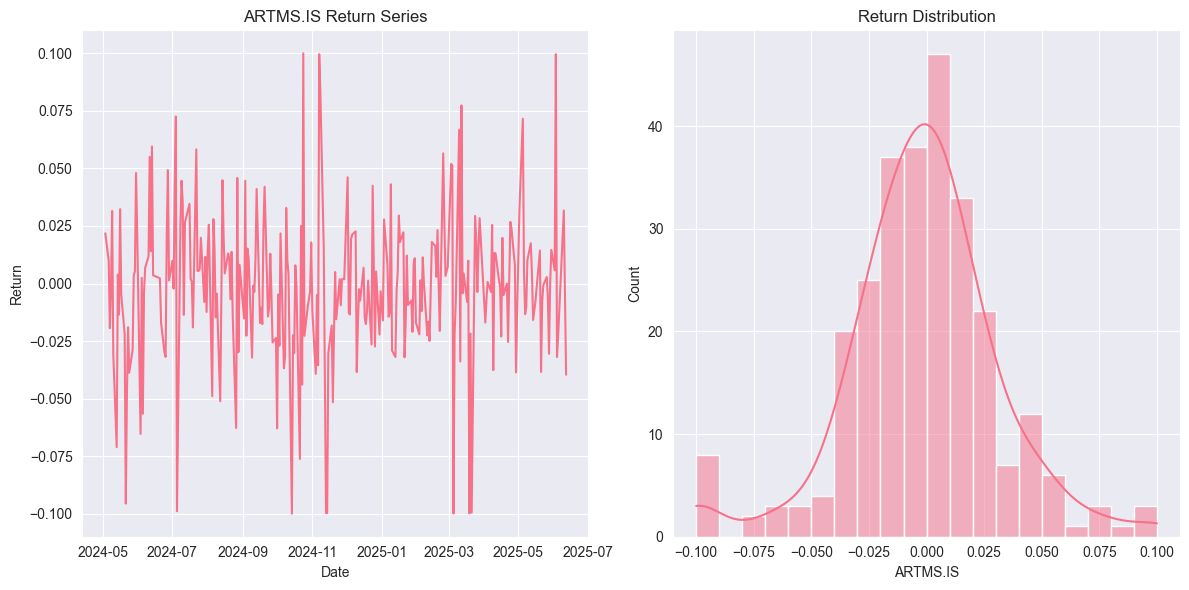


=== ARTMS.IS Analysis ===
Mean Return: -0.0018
Volatility: 0.0329
Skewness: -0.2112
Kurtosis: 1.8399

Stationarity (ADF) Test p-value: 0.0001


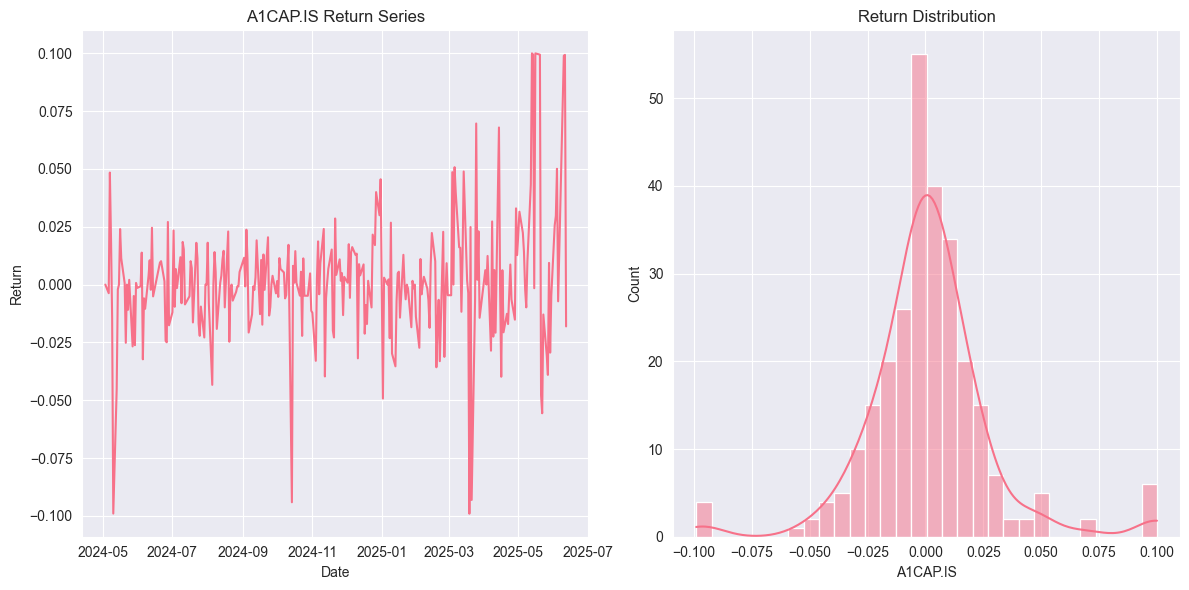


=== A1CAP.IS Analysis ===
Mean Return: 0.0012
Volatility: 0.0267
Skewness: 0.4352
Kurtosis: 4.9057

Stationarity (ADF) Test p-value: 0.0000


In [95]:
from statsmodels.tsa.stattools import adfuller

def simple_ts_analysis(series, stock_name):
    # Visual settings
    plt.figure(figsize=(12, 6))

    # Plot returns
    plt.subplot(1, 2, 1)
    plt.plot(series)
    plt.title(f'{stock_name} Return Series')
    plt.xlabel('Date')
    plt.ylabel('Return')

    # Distribution plot
    plt.subplot(1, 2, 2)
    sns.histplot(data=series, kde=True)
    plt.title('Return Distribution')

    plt.tight_layout()
    plt.show()

    # Basic statistics
    print(f"\n=== {stock_name} Analysis ===")
    print(f"Mean Return: {series.mean():.4f}")
    print(f"Volatility: {series.std():.4f}")
    print(f"Skewness: {series.skew():.4f}")
    print(f"Kurtosis: {series.kurt():.4f}")

    # Stationarity Test
    adf_result = adfuller(series.dropna())
    print(f"\nStationarity (ADF) Test p-value: {adf_result[1]:.4f}")

# Run analysis for each stock
for stock in d_returns.columns:
    simple_ts_analysis(d_returns[stock], stock)

Drawdown & Risk Analysis

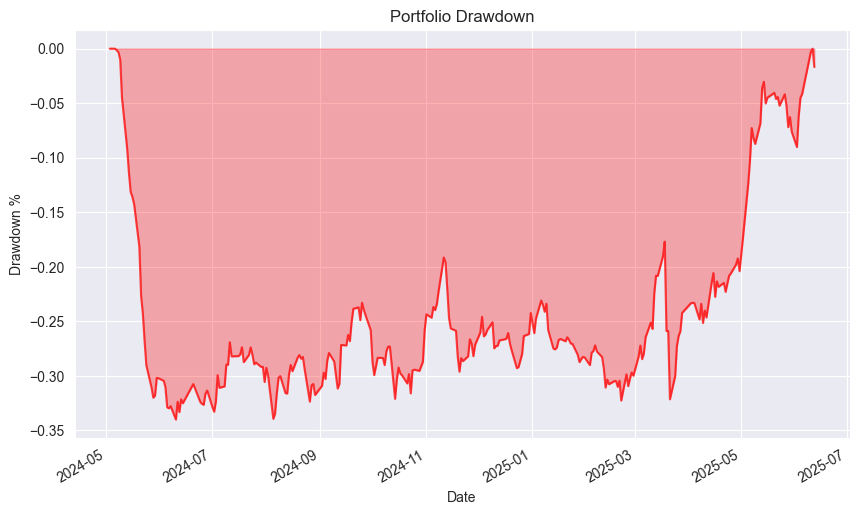

Maximum Drawdown: -34.01%


In [96]:
# Step 1: Drawdown
def calculate_simple_drawdown(prices):
    peak = prices.expanding(min_periods=1).max()
    drawdown = (prices - peak) / peak
    return drawdown

# Drawdown for the portfolio
portfolio_prices = (1 + portfolio_returns).cumprod()
portfolio_drawdown = calculate_simple_drawdown(portfolio_prices)

# Plot
plt.figure(figsize=(10, 6))
portfolio_drawdown.plot(color='red', alpha=0.7)
plt.fill_between(portfolio_drawdown.index, portfolio_drawdown, 0, color='red', alpha=0.3)
plt.title('Portfolio Drawdown')
plt.ylabel('Drawdown %')
plt.grid(True)
plt.show()

# Largest fall from a peak
print(f"Maximum Drawdown: {portfolio_drawdown.min():.2%}")

In [97]:
# Step 2: Basic risk metrics
risk_metrics = {
    'Volatility (Annual)': portfolio_returns.std() * np.sqrt(252),
    'Largest Daily Loss': portfolio_returns.min(),
    'Largest Daily Gain': portfolio_returns.max(),
    'VaR (95%)': portfolio_returns.quantile(0.05)
}

for metric, value in risk_metrics.items():
    print(f"{metric}: {value:.2%}")

Volatility (Annual): 32.60%
Largest Daily Loss: -9.96%
Largest Daily Gain: 5.95%
VaR (95%): -3.15%


In [98]:
# VaR at different confidence levels
confidence_levels = [0.90, 0.95, 0.99]
var_analysis = {}

for conf in confidence_levels:
    var = portfolio_returns.quantile(1-conf)
    var_analysis[f"VaR ({conf:.0%})"] = var

print("\nVaR at Different Confidence Levels:")
for var_type, value in var_analysis.items():
    print(f"{var_type}: {value:.2%}")


VaR at Different Confidence Levels:
VaR (90%): -2.28%
VaR (95%): -3.15%
VaR (99%): -5.89%



Up/Down Day Analysis:
Up Days: 145 days (52.5%)
Down Days: 130 days (47.1%)


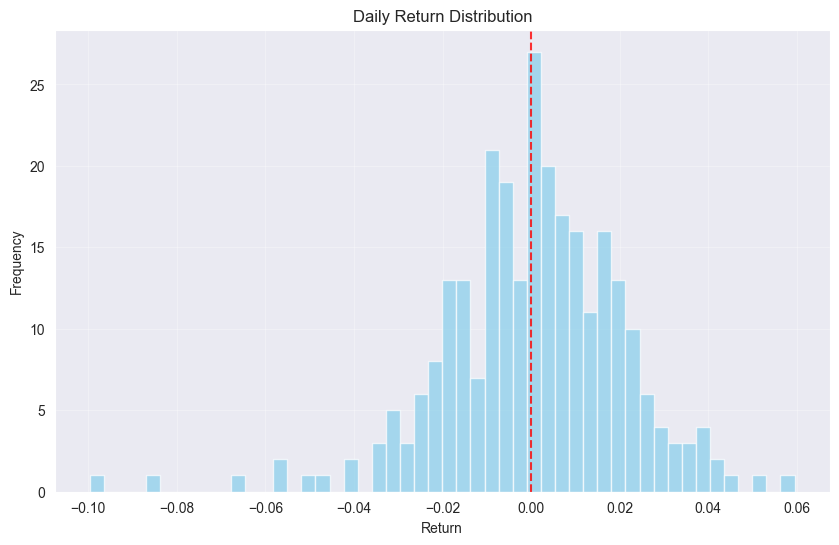

In [99]:
# Step 3: Up and down days
positive_days = len(portfolio_returns[portfolio_returns > 0])
negative_days = len(portfolio_returns[portfolio_returns < 0])
total_days = len(portfolio_returns)

print("\nUp/Down Day Analysis:")
print(f"Up Days: {positive_days} days ({positive_days/total_days:.1%})")
print(f"Down Days: {negative_days} days ({negative_days/total_days:.1%})")

# Plot
plt.figure(figsize=(10, 6))
plt.hist(portfolio_returns, bins=50, color='skyblue', alpha=0.7)
plt.axvline(x=0, color='red', linestyle='--', alpha=0.8)
plt.title('Daily Return Distribution')
plt.xlabel('Return')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.show()

# Final Report Dashboard
This section summarizes portfolio performance, optimization, diversification, and risk metrics in one place.


Portfolio Summary Metrics:
Expected Return (Optimized): 53.39%
Volatility (Optimized): 43.75%
Sharpe Ratio (Optimized): 0.12
Expected Return (Equal Weight): 6.99%
Volatility (Equal Weight): 32.60%
Sharpe Ratio (Equal Weight): -1.26
Max Drawdown: -34.01%
VaR (95%): -3.15%


,Stock,Optimal Weight (%)
KZBGY.IS,KZBGY.IS,65.68
ISGSY.IS,ISGSY.IS,12.15
KTLEV.IS,KTLEV.IS,0.70
ARTMS.IS,ARTMS.IS,5.31
A1CAP.IS,A1CAP.IS,16.16


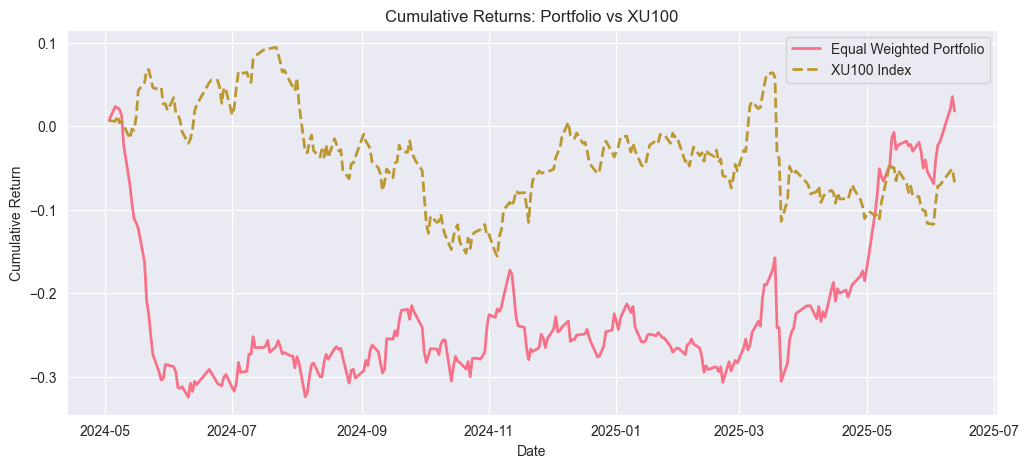

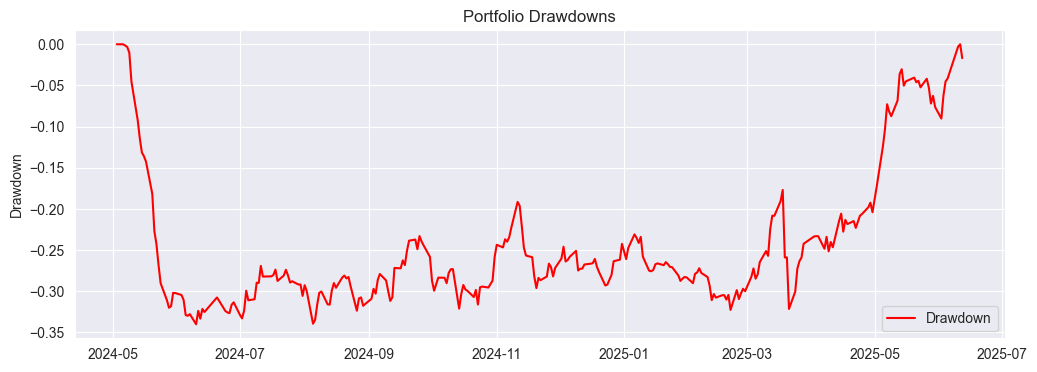

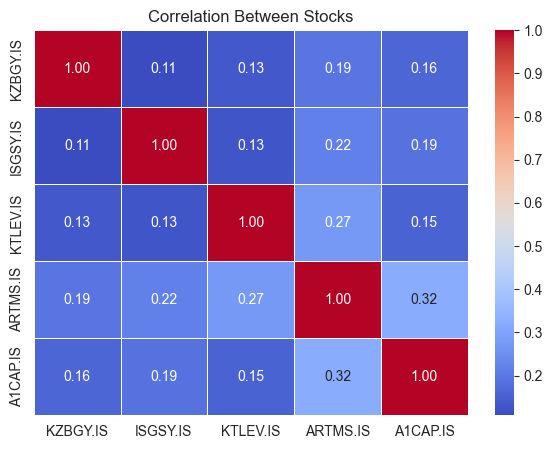


CAPM Regression Summary (Stock ~ XU100):

--- KZBGY.IS ---
Alpha:       0.003040
Beta:        0.6712
R-squared:   0.0757
P-value (β): 0.0000

--- ISGSY.IS ---
Alpha:       0.000901
Beta:        0.8720
R-squared:   0.1629
P-value (β): 0.0000

--- KTLEV.IS ---
Alpha:       -0.001652
Beta:        0.4999
R-squared:   0.0346
P-value (β): 0.0020

--- ARTMS.IS ---
Alpha:       -0.001738
Beta:        0.7194
R-squared:   0.1173
P-value (β): 0.0000

--- A1CAP.IS ---
Alpha:       0.001295
Beta:        0.7613
R-squared:   0.1997
P-value (β): 0.0000


In [100]:
# ---- 1. Portfolio Metrics Summary ----
summary_metrics = {
    "Expected Return (Optimized)": f"{optimal_portfolio['Return']:.2%}",
    "Volatility (Optimized)": f"{optimal_portfolio['Volatility']:.2%}",
    "Sharpe Ratio (Optimized)": f"{optimal_portfolio['Sharpe']:.2f}",
    "Expected Return (Equal Weight)": f"{equal_return:.2%}",
    "Volatility (Equal Weight)": f"{equal_volatility:.2%}",
    "Sharpe Ratio (Equal Weight)": f"{equal_sharpe:.2f}",
    "Max Drawdown": f"{portfolio_drawdown.min():.2%}",
    "VaR (95%)": f"{portfolio_returns.quantile(0.05):.2%}"
}

print("\nPortfolio Summary Metrics:")
for k, v in summary_metrics.items():
    print(f"{k}: {v}")

# ---- 2. Show Final Portfolio Weights ----
opt_weights_df = pd.DataFrame({
    'Stock': d_returns.columns,
    'Optimal Weight (%)': np.round(optimal_portfolio[3:] * 100, 2)
})
display(opt_weights_df)

# ---- 3. Cumulative Returns Plot ----
plt.figure(figsize=(12, 5))
plt.plot(portfolio_cum_returns, label='Equal Weighted Portfolio', linewidth=2)
plt.plot(index_cum_returns, label='XU100 Index', linestyle='--', linewidth=2)
plt.title('Cumulative Returns: Portfolio vs XU100')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True)
plt.show()

# ---- 4. Drawdown Plot ----
plt.figure(figsize=(12, 4))
plt.plot(portfolio_drawdown, color='red', label='Drawdown')
plt.title('Portfolio Drawdowns')
plt.ylabel('Drawdown')
plt.grid(True)
plt.legend()
plt.show()

# ---- 5. Correlation Heatmap ----
plt.figure(figsize=(7, 5))
sns.heatmap(d_returns.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Between Stocks')
plt.show()

# ---- 6. CAPM Regression Alphas & Betas ----
print("\nCAPM Regression Summary (Stock ~ XU100):")
for stock in d_returns.columns:
    reg_data = pd.DataFrame({
        'stock': d_returns[stock],
        'market': index_returns
    }).dropna()

    Y = reg_data['stock']
    X = sm.add_constant(reg_data['market'])
    model = sm.OLS(Y, X).fit()

    print(f"\n--- {stock} ---")
    print(f"Alpha:       {model.params.iloc[0]:.6f}")
    print(f"Beta:        {model.params.iloc[1]:.4f}")
    print(f"R-squared:   {model.rsquared:.4f}")
    print(f"P-value (β): {model.pvalues.iloc[1]:.4f}")

In [101]:
portfolio_cum_returns.iloc[-1]

np.float64(0.017990757666931367)